<div class="alert alert-block alert-danger">
    <b> UNTANGLING THE CYTOSKELETON: A MODEL TO DESCRIBE CYTOSKELETAL ORGANIZATION - CODE</b> 
    
 **2 - CYTOSKELETON PREPROCESSING**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
pip list

Package                           Version
--------------------------------- -----------
absl-py                           1.4.0
alabaster                         0.7.13
altgraph                          0.17.3
anyio                             3.6.2
app-model                         0.1.1
appdirs                           1.4.4
argon2-cffi                       21.3.0
argon2-cffi-bindings              21.2.0
arrow                             1.2.3
asttokens                         3.0.0
astunparse                        1.6.3
asv                               0.5.1
async-lru                         2.0.5
attrs                             22.2.0
Babel                             2.11.0
backcall                          0.2.0
beautifulsoup4                    4.11.1
beniget                           0.4.1
bidict                            0.22.1
biosppy                           1.0.0
bleach                            6.0.0
blinker                           1.9.0
blosc2                  

In [1]:
import os
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
import sys
sys.path.append(os.path.abspath('..'))
from packageCYSK.importing import *
from packageCYSK.preprocessingCYTO import *

print('📚 All libraries successfully imported 📚')

📚 All libraries successfully imported 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [2]:
# Define dataset folder.
folder      = os.getcwd() + "\\data"

# Import images from CYTO folders.
options     = ["CYTO"]

# Dictionary with key "CYTO"
data = init_import(folder,options)

#data['CYTO_PRE'] = pd.read_pickle(folder + "\\CYTO_PRE\\CYTO_PRE.pkl") 

Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [CYTO] added.


In [3]:
data['CYTO']

,Path,Name,Label,Label 2,Resolution,Image,Image Size
HPA,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,Cells,abc.tif,"(1, 0.08, 0.08)","[[0, 0, 0, 0, 0, 0, 0, 38, 146, 80, 0, 0, 0, 0...","(2048, 2048)"


<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**1.** Select an image.

**2.** Perform cytoskeleton preprocessing to the selected image. Tune the necessary parameters. Once satisfied with the results, save the textures and skeletons on ```data['CYTO_PRE']```. 

**3.** If you have a dataset of images, repeat this process with another image. In the end, ```data['CYTO_PRE']``` must be filled with cytoskeletons (textures and skeletons) identified from multiple images. 

**4.** Save the final dataframe.

<div class="alert alert-block alert-info">
    
 **SELECT IMAGE**
    
</div>

In [4]:
def dropdown_image_eventhandler(change):
    global idx
    idx = dropdown_image.value
    lab = data['CYTO']['Label'][dropdown_image.value]
    print('Image ' + str(idx) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Image:' , options = ['...'] + list(data['CYTO'].index))
dropdown_image.observe(dropdown_image_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Image:', options=('...', 'HPA'), value='...')

Image HPA (Cells) selected.


<div class="alert alert-block alert-info">
    
 **CYTOSKELETON PREPROCESSING**
    
</div>

In [18]:
def cytoskeleton_preprocessing_hpa(rowCYTO, parameters, plot, save):
    """
    Preprocessing of a cytoskeleton image.
        - ```rowCYTO```      = row of data['CYTO'] 
        - ```parameters```   = dict with tunable parameters
        - ```plot```         = True: plot results
        - ```save```         = True: save preprocessing byproducts in directory
    """
    
    global CYTO_PRE
    
    # Get image
    image = [rowCYTO['Image'],rowCYTO.name]
    
    # CROP!!!!!!!!!!!!!
    image[0] = image[0][170:850,0:380]

    
    ### PIPELINE
    # Retrieve image
    ini = image[0] / np.max(image[0])
    
    # Denoise
    from skimage.morphology import white_tophat, disk
    from skimage import img_as_float
    from bm3d import bm3d, BM3DProfile
    from skimage.exposure import rescale_intensity

    # Apply Anscombe transform
    vst = 2 * np.sqrt(ini + 3/8)

    # Denoise with BM3D
    denoised_vst = bm3d(img_as_float(vst), sigma_psd=0.2,profile='np')

    # Inverse Anscombe
    denoised = (denoised_vst**2 - 3/8) / 4

    # Rescale intensity
    denoised_rescaled = rescale_intensity(denoised, in_range='image', out_range=(0, 1))

    # Background removal
    denoised_ = white_tophat(denoised_rescaled, footprint=disk(11))  # tune radius
    
    


    
#     if 'clahe_clip' in parameters:
#         clahe_image = equalize_adapthist(gau/np.max(gau), clip_limit=parameters['clahe_clip'])
#         clahe_image = clahe_image / np.max(clahe_image)
#         from skimage.restoration import denoise_tv_chambolle
#         #clahe_image = denoise_tv_chambolle(gau, weight=0.1)
#         from skimage.morphology import white_tophat, disk
#         #background = gaussian(gau, sigma=85.0)  # low-freq background
#         #clahe_image = gau - background
#         #clahe_image[clahe_image < 0] = 0
#         from bm3d import bm3d, BM3DProfile


#         #clahe_image = bm3d(img_as_float(gau), sigma_psd=0.01, profile=BM3DProfile('high'))
        
#         import pywt
#         import pywt.data
        
#         def wavelet_denoise(image, wavelet='db2', level=3, sigma=0.05):
#             """
#             Apply wavelet-based denoising using soft thresholding.
#             """
#             coeffs = pywt.wavedec2(image, wavelet=wavelet, level=level)

#             # Estimate universal threshold
#             tau = sigma * np.sqrt(2 * np.log(image.size))

#             # Threshold all detail coefficients
#             coeffs_thresh = [coeffs[0]]  # Keep approximation unmodified
#             for detail_level in coeffs[1:]:
#                 cH, cV, cD = detail_level
#                 cH = pywt.threshold(cH, tau, mode='soft')
#                 cV = pywt.threshold(cV, tau, mode='soft')
#                 cD = pywt.threshold(cD, tau, mode='soft')
#                 coeffs_thresh.append((cH, cV, cD))

#             # Reconstruct
#             denoised = pywt.waverec2(coeffs_thresh, wavelet=wavelet)
#             return np.clip(denoised, 0, 1)
        
#         #coeffs = pywt.wavedec2(gau, 'db2', level=2)
#         #coeffs_thresh = [(pywt.threshold(c, 0.02, 'soft') if isinstance(c, np.ndarray) else c) for c in coeffs]
#         #clahe_image = pywt.waverec2(coeffs_thresh, 'db2')
        
#         from skimage.restoration import estimate_sigma
#         #segma = estimate_sigma(gau)
#         #print(segma)
#         #clahe_image = wavelet_denoise(gau, wavelet='db2', level=2, sigma=segma)
        

#     try:
#         #s   = sato(clahe_image,black_ridges=False,sigmas=[parameters['sato_sigma']],mode='reflect')  #old:sigmas[1]
        
#         s   = sato(clahe_image_,black_ridges=False,sigmas=np.linspace(2.5, 4.5, 4),mode='reflect')
#         #s   = meijering(clahe_image,black_ridges=False,sigmas=np.linspace(2, 4, 4),mode='reflect')
#     except:
#         s   = sato(gau,black_ridges=False,sigmas=[parameters['sato_sigma']],mode='reflect')  #old:sigmas[1]
    h   = hessian(denoised_,black_ridges=False,alpha = 0.3,beta = 0.05,gamma=15,sigmas=[parameters['hess_sigma']],mode='reflect')    #old:sigmas[0.006]
    #h   = hessian(clahe_image_,black_ridges=False,alpha = 0.3,beta = 0.05,gamma=15,sigmas=[0.37],mode='reflect')    #old:sigmas[0.006]
    
    #h   = hessian(clahe_image,black_ridges=False,alpha = 0.5,beta = 0.5,gamma=15,sigmas=np.linspace(0.33,0.36,3),mode='reflect')    #old:sigmas[0.006]
    
    tex = ((1 - h)!=0)*1
    copy_tex = copy.deepcopy(tex)

    ske = skeletonize(tex)
    copy_sk            = np.array(copy.deepcopy(ske*1))
       
    
    ### SIZE FILTER
    from skimage.measure import label, regionprops
    ske_       = Skeleton(skeleton_image = (ske*1).astype(float)) # ResultsRow['Resolution'][2] ou [1] ou os dois
    
    
    
    skeleton_info = summarize(ske_)
    junction_pixels = skeleton_info[skeleton_info['branch-type'] > 0][['image-coord-src-0', 'image-coord-src-1']].values
    junction_set = set(map(tuple, junction_pixels))

    # Iterate over branches and remove short ones, excluding junction pixels
    for br in range(ske_.n_paths):
        brcoords = ske_.path_coordinates(br)

        if len(brcoords) < 5:
            for j in range(len(brcoords)):
                coord = (int(brcoords[j][0]), int(brcoords[j][1]))
                # Check if the coordinate is a junction before deleting

                if coord not in junction_set:
                    copy_sk[coord] = 0
    
    # DELETE SINGLE PIXELS
    labeled_image = label(copy_sk*1)
    min_area = 7
    for region in regionprops(labeled_image):
        if int(region.area) <= int(min_area):
            copy_sk[labeled_image == region.label] = 0
    
    
#     for br in range(ske_.n_paths):
#         brcoords = ske_.path_coordinates(br)
#         if len(brcoords) < 5:
            
#             for j in range(len(brcoords)):
#                 copy_sk[int(brcoords[j][0]),int(brcoords[j][1])] = 0
    
    
    
#     labeled_image = label(copy_tex*1)
#     min_area = 6
#     for region in regionprops(labeled_image):
#         if region.area < min_area:
#             copy_tex[labeled_image == region.label] = 0
#     ###
#     skele = skeletonize(copy_tex)
    
    
#     from skimage.measure import label, regionprops
#     ske_       = Skeleton(skeleton_image = (skele*1).astype(float)) # ResultsRow['Resolution'][2] ou [1] ou os dois
    
#     for br in range(ske_.n_paths):
#         brcoords = ske_.path_coordinates(br)
#         if len(brcoords) < 5:
            
#             for j in range(len(brcoords)):
#                 skele[int(brcoords[j][0]),int(brcoords[j][1])] = 0
    
    labeled_mask = label(copy_tex*1)  # Label connected regions in the texture
    for region in regionprops(labeled_mask):
        # Extract coordinates of the region
        coords = region.coords

        # Check if any of these pixels are part of the skeleton
        if not np.any([copy_sk[c[0], c[1]] for c in coords]):
            # If no skeleton pixel inside, delete the region from the texture
            for c in coords:
                copy_tex[c[0], c[1]] = 0
            
    
    
    
    # List titles and images
    titulos = ['original2','denoised2','hessian2','skeleton2']
    imagens = [ini,denoised_,copy_tex,copy_sk]
    
    
 
    # Plot results
    if plot:
        for titulo,imagem in list(zip(titulos,imagens)):
            imageshow(image   = imagem,
                      figsize = (15,15),
                      inv     = True,
                      title   = titulo,
                      save    = save)
            
    if save:
        print("oi")
        
        for titulo,imagem in list(zip(titulos,imagens)):
            #x_,y_   = np.where((copy_tex*1) != 0) # resolver aqui para fazer um retangulo de branco com pad2 para as figuras ficarem direitas?
            #imagem   = imagem[min(x_):max(x_),min(y_):max(y_)]
            #cv2.imwrite(os.path.join("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA","figs","fig2_new",titulo + ".png"),(255*(np.max(imagem)-imagem)/np.max(imagem)).astype(np.uint8))
            
            cv2.imwrite(os.path.join("C:\\Users\\diogo\\OneDrive - Universidade de Lisboa\\Ambiente de Trabalho\\WORK\\202402 - Paper SOTA","figs","fig2_final",titulo + ".png"),(255*(np.max(imagem)-imagem)/np.max(imagem)).astype(np.uint8))
       
            
    # Add textures and skeletons to CYTO_PRE
    if 'CYTO_PRE' not in globals():
        CYTO_PRE = pd.DataFrame(columns=['Path','Name','Img Index','Label','Image Size','Texture','Skeleton'])
    new = pd.DataFrame(data={'Path': [rowCYTO['Path']], 
                             'Name': [rowCYTO['Name']], 
                        'Img Index': [rowCYTO.name], 
                            'Label': [rowCYTO['Label']], 
                       'Image Size': [rowCYTO['Image Size']],
                          'Texture': [copy_tex], 
                         'Skeleton': [copy_sk*1]}, index = [rowCYTO.name])
    CYTO_PRE = pd.concat([CYTO_PRE, new],ignore_index=False)
    
    return CYTO_PRE,imagens




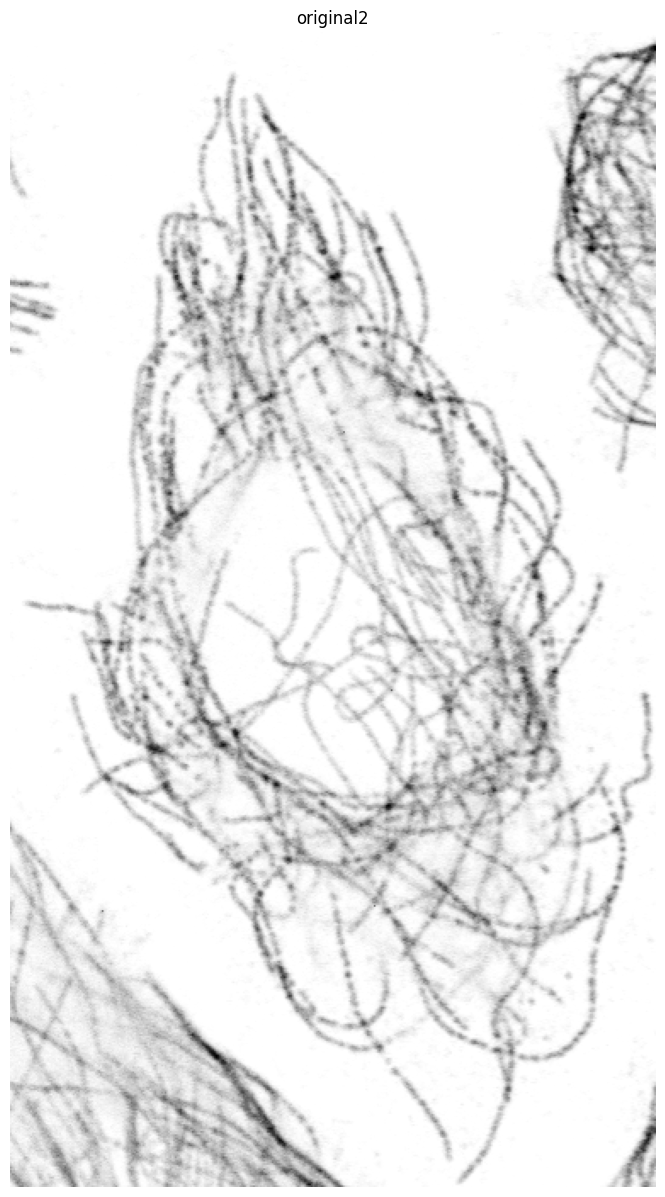

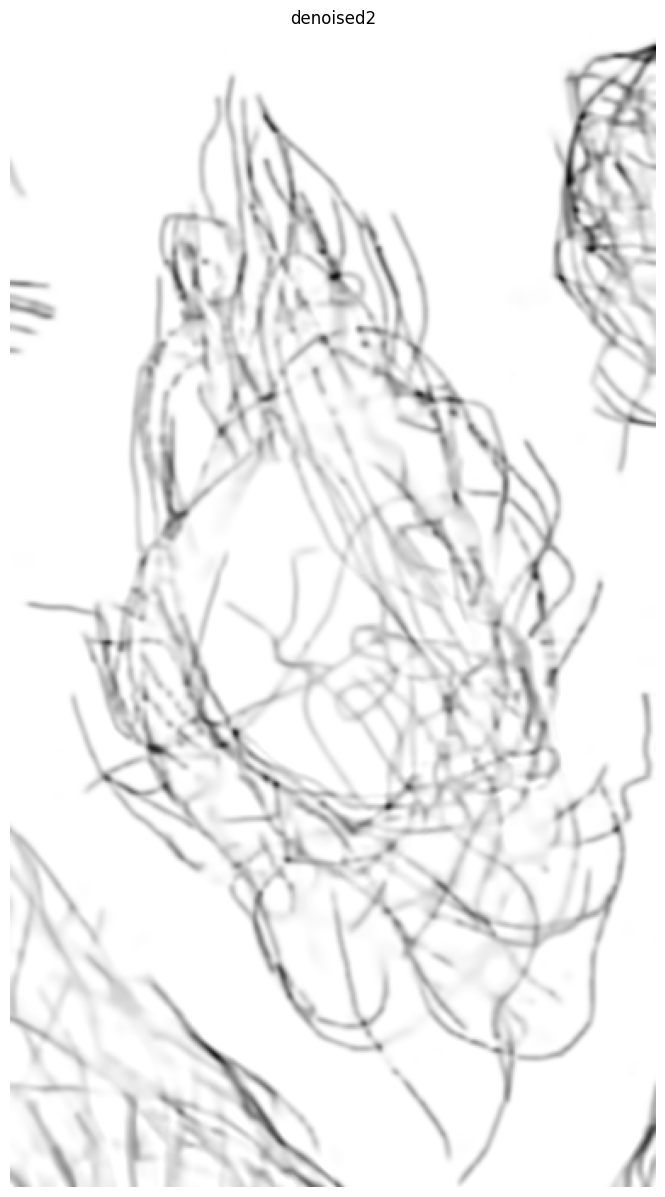

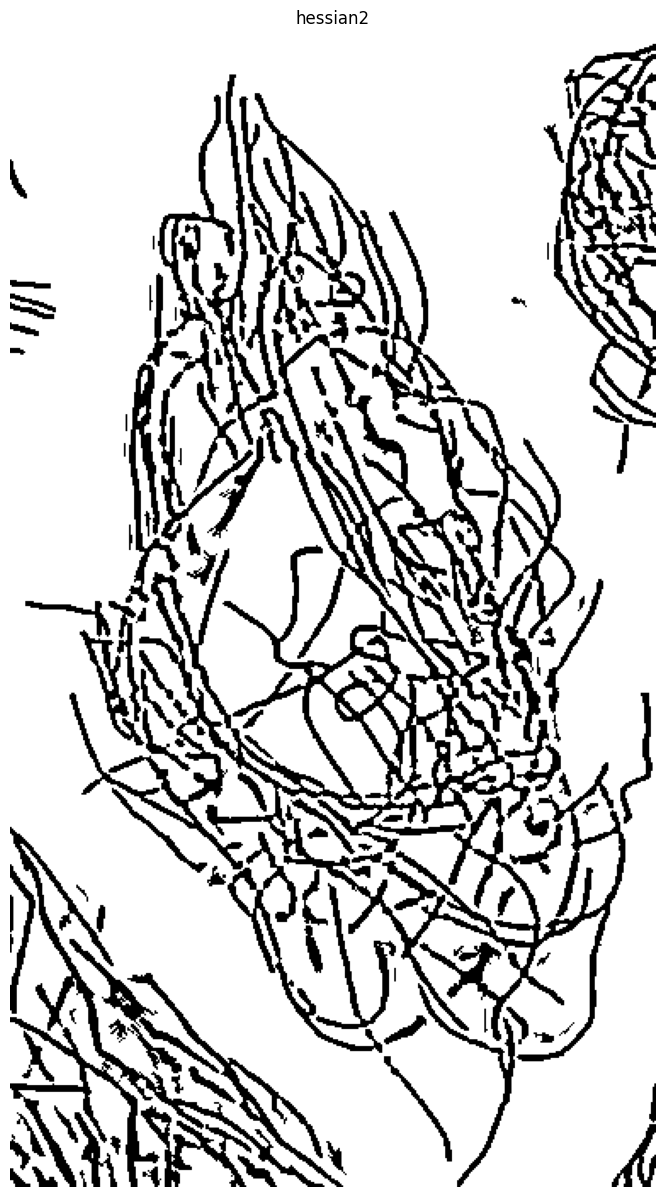

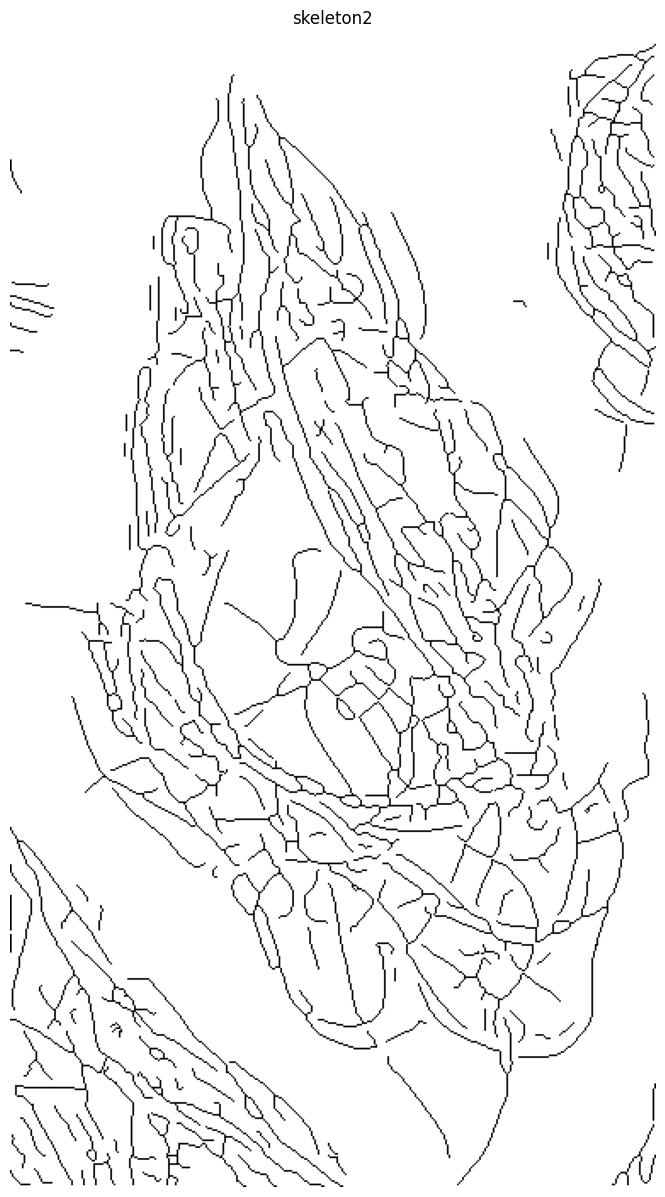

oi


In [19]:
data['CYTO_PRE'],imagens = cytoskeleton_preprocessing_hpa(rowCYTO = data['CYTO'].loc[idx],
                                                       parameters = {'gau_sigma': 0.2,
                                                                     'clahe_clip': 0.005,
                                                                     'sato_sigma': 3,
                                                                     'hess_sigma': 0.36}, #0.33
                                                             plot = True,
                                                             save = True) #save=folder+"\\" + str(image_id))


In [45]:
data['CYTO_PRE'].index = ['HPA']

In [46]:
data['CYTO_PRE']

,Path,Name,Img Index,Label,Image Size,Texture,Skeleton
HPA,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [42]:
data['CYTO_PRE'] = data['CYTO_PRE'].iloc[1:].reset_index(drop=True)

# SOAX -> TEXTURE AND SKELETON

In [25]:
#from packageCYSK.feature_extraction import *
data['filaments'],data['junctions'] = read_soax_txt('snakes_june2.txt')

Filament DataFrames:
Filament 1:
Empty DataFrame
Columns: [s, p, x, y, z, fg_int, bg_int]
Index: [] 

Filament 2:
    s   p        x        y  z    fg_int   bg_int
0   0   0  182.815  225.564  0   99.1340  62.1962
1   0   1  183.609  224.951  0  111.4750  55.9189
2   0   2  184.406  224.341  0  105.5640  51.3147
3   0   3  185.202  223.730  0   96.4156  47.3297
4   0   4  185.999  223.121  0   85.7624  45.0114
5   0   5  186.794  222.510  0   74.9586  45.1829
6   0   6  187.579  221.886  0   71.1481  44.6455
7   0   7  188.345  221.237  0   68.4378  44.7556
8   0   8  189.090  220.565  0   70.7381  44.7189
9   0   9  189.829  219.887  0   74.8950  42.9823
10  0  10  190.576  219.217  0   78.8565  40.5487
11  0  11  191.332  218.558  0   83.2156  38.5604
12  0  12  192.101  217.913  0   90.4856  36.4277
13  0  13  192.881  217.283  0   94.5001  35.1149
14  0  14  193.672  216.666  0   98.9197  33.6451
15  0  15  194.464  216.049  0  106.2850  32.6343
16  0  16  195.234  215.407  0  111.

     s   p        x        y  z    fg_int    bg_int
0   58   0  314.465  235.930  0   21.6126   6.74474
1   58   1  314.960  236.810  0   19.0056  15.03180
2   58   2  315.410  237.714  0   20.3462  18.16690
3   58   3  315.744  238.667  0   28.7043  20.77950
4   58   4  315.961  239.653  0   44.0677  27.18930
5   58   5  316.194  240.635  0   60.7980  30.88370
6   58   6  316.517  241.592  0   72.6523  22.17410
7   58   7  316.986  242.486  0   78.8850  11.80720
8   58   8  317.566  243.313  0   80.0698   6.74980
9   58   9  318.193  244.104  0   84.3788   5.89992
10  58  10  318.817  244.898  0   86.3753   6.63407
11  58  11  319.403  245.720  0   85.3403   7.25600
12  58  12  319.925  246.585  0   84.4910   6.58956
13  58  13  320.350  247.500  0   81.6734   4.81567
14  58  14  320.647  248.465  0   79.0508   4.26397
15  58  15  320.799  249.464  0   75.4780   3.71396
16  58  16  320.810  250.473  0   70.4916   3.41788
17  58  17  320.696  251.476  0   65.5594   3.12986
18  58  18  

       s    p        x        y  z    fg_int     bg_int
0    109    0  230.810  470.083  0  89.04210  91.347800
1    109    1  231.238  470.985  0  88.59690  89.764000
2    109    2  231.812  471.802  0  72.91400  66.073700
3    109    3  232.474  472.548  0  53.78770  46.319800
4    109    4  233.137  473.295  0  42.45490  32.162500
..   ...  ...      ...      ... ..       ...        ...
109  109  109  224.618  572.374  0  31.89110   0.468105
110  109  110  224.262  573.307  0  19.82180   0.328291
111  109  111  223.837  574.209  0  10.02920   0.212926
112  109  112  223.336  575.073  0   4.47705   0.124039
113  109  113  222.796  575.912  0   1.95342   0.029933

[114 rows x 7 columns] 

Filament 112:
      s   p        x        y  z    fg_int   bg_int
0   110   0  272.890  159.415  0  134.6880  81.0779
1   110   1  272.879  160.418  0  122.1190  67.3771
2   110   2  273.053  161.406  0   88.7819  81.7800
3   110   3  273.319  162.373  0   57.2637  65.4640
4   110   4  273.566  163.34

In [11]:
data['CYTO_PRE']['Texture'][0].shape

(680, 380)

In [16]:
data

<module 'skimage.data' from 'C:\\Users\\diogo\\anaconda3\\envs\\Cytosk_recentpy\\lib\\site-packages\\skimage\\data\\__init__.py'>

In [38]:
data['CYTO_PRE']

KeyError: 'CYTO_PRE'

(680, 380)


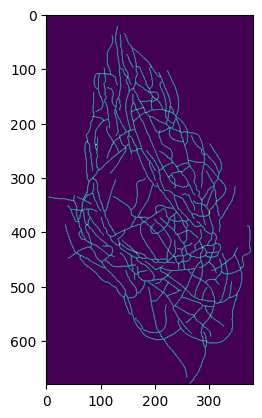

In [47]:
skeletoni = np.zeros((680, 380))
for filament in data['filaments']:

    x = [int(a) for a in filament['x']] 
    y = [int(b) for b in filament['y']]

    skeletoni[np.array(y),np.array(x)] = 1
    
for index,row in data['junctions'].iterrows():

    skeletoni[int(row[1]),int(row[0])] = 1

skeletoni = np.flipud(skeletoni)
print(np.shape(skeletoni))
plt.imshow(skeletoni)

In [52]:
skeletoni.shape

(680, 380)

In [54]:
data['CYTO_PRE'].loc['HPA']['Skeleton'] = skeletoni

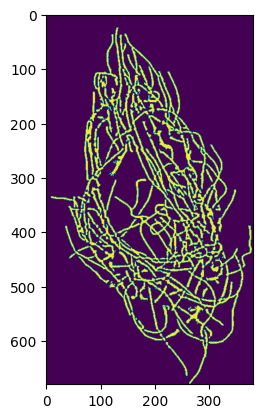

In [56]:
from skimage.measure import label, regionprops
mask = data['CYTO_PRE'].loc['HPA']['Texture']*1
labeled_mask = label(mask)  # Label connected regions in the texture

for region in regionprops(labeled_mask):
    # Extract coordinates of the region
    coords = region.coords

    # Check if any of these pixels are part of the skeleton
    if not np.any([skeletoni[c[0], c[1]] for c in coords]):
        # If no skeleton pixel inside, delete the region from the texture
        for c in coords:
            mask[c[0], c[1]] = 0
            


In [57]:
data['CYTO_PRE'].loc['HPA']['Texture'] = mask

In [66]:
compar.loc['HPA']['Texture']  = np.pad(compar.loc['HPA']['Texture'], ((170, 1198), (0, 1668)), mode='constant')
compar.loc['HPA']['Skeleton'] = np.pad(compar.loc['HPA']['Skeleton'], ((170, 1198), (0, 1668)), mode='constant')

In [ ]:
restored = np.pad(image[0], ((170, 1198), (0, 1668)), mode='constant')

In [ ]:
from skimage.morphology import binary_dilation, disk
from skimage.measure import find_contours

# Dilate to close gaps between filaments
image = data['CYTO_PRE'].loc['HPA']['Texture']
dilated = binary_dilation(image, disk(6))  # increase disk radius for looser fit

# Get outermost contour
contours = find_contours(dilated, level=0.5)
outer = max(contours, key=len)

# Plot
#fig, ax = plt.subplots()
#ax.imshow(image, cmap='gray')
#ax.plot(outer[:, 1], outer[:, 0], color='red')
#plt.title("Smoothed Outer Shape")
#plt.axis('off')
#plt.show()

from skimage.draw import polygon

# Create blank mask
mask_filled = np.zeros_like(image, dtype=bool)

# Convert contour coordinates to row, col integers
rr, cc = polygon(outer[:, 0], outer[:, 1], image.shape)

# Fill mask
mask_filled[rr, cc] = True

# Plot filled region
fig, ax = plt.subplots()
ax.imshow(mask_filled, cmap='gray')
#ax.set_title("Filled Outer Shape")
ax.axis('off')
plt.show()


#ResultsDF['Patch:Cyto Mask Filled'] = [np.array(mask_filled * 1)]
data['CYTO_PRE']['Mask Filled'] = [np.array(mask_filled * 1)]

<div class="alert alert-block alert-info">
    
 **SAVE DATAFRAME**
    
</div>

In [58]:
data['CYTO_PRE']

,Path,Name,Img Index,Label,Image Size,Texture,Skeleton
HPA,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [68]:
compar.to_pickle(folder + "//CYTO_PRE//CYTO_PRE_FINAL.pkl")

---

In [65]:
compar = pd.read_pickle(folder + "\\CYTO_PRE\\CYTO_PRE_FINAL.pkl") 

In [67]:
compar.loc['HPA']['Texture'].shape

(2048, 2048)

In [ ]:
compar